# Benchmark Analysis

This notebook preprocesses the benchmark results and plots the evolution of latency against variables $N$, $\alpha$, and $T_{le}$.  
Please change the network_latency_dist variable on top of the next cell to use the correct network latency distribution.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

network_latency_dist = "N(10,5)"

sns.set_theme(style="whitegrid")

# Configuration for saving plots
output_dir = f"graphs/{network_latency_dist}"
os.makedirs(output_dir, exist_ok=True)

# 1. Load the data
# Use skipinitialspace to handle " Alpha" vs "Alpha" if there are spaces after commas
df = pd.read_csv(f"../results_{network_latency_dist}.csv", skipinitialspace=True)

# Ensure columns have no surrounding whitespace
df.columns = [col.strip() for col in df.columns]

# 2. Preprocess: drop 'Did not finish'
df_completed = df[df['Latency'].astype(str).str.strip() != 'DNF'].copy()

# Convert Latency to numeric
df_completed['Latency'] = pd.to_numeric(df_completed['Latency'])

# 3. Calculate average latency across the 5 seeds for each experiment setup
avg_df = df_completed.groupby(['N', 'f', 'Alpha', 'T_le'])['Latency'].mean().reset_index()

print(f"Original records: {len(df)}")
print(f"Records after removing 'DNF': {len(df_completed)}")
print(f"Number of unique experments: {len(avg_df)}")
avg_df.head()

Original records: 450
Records after removing 'DNF': 450
Number of unique experments: 90


,N,f,Alpha,T_le,Latency
0,3,1,0.0,10,48.4
1,3,1,0.0,20,53.2
2,3,1,0.0,30,74.6
3,3,1,0.0,50,78.0
4,3,1,0.0,100,94.2


## Evolution of Latency with N
Latency vs N as multiple curves, one curve per $T_{le}$ value. Using $\alpha=0$ as baseline and $\alpha=0.1$ as comparison.

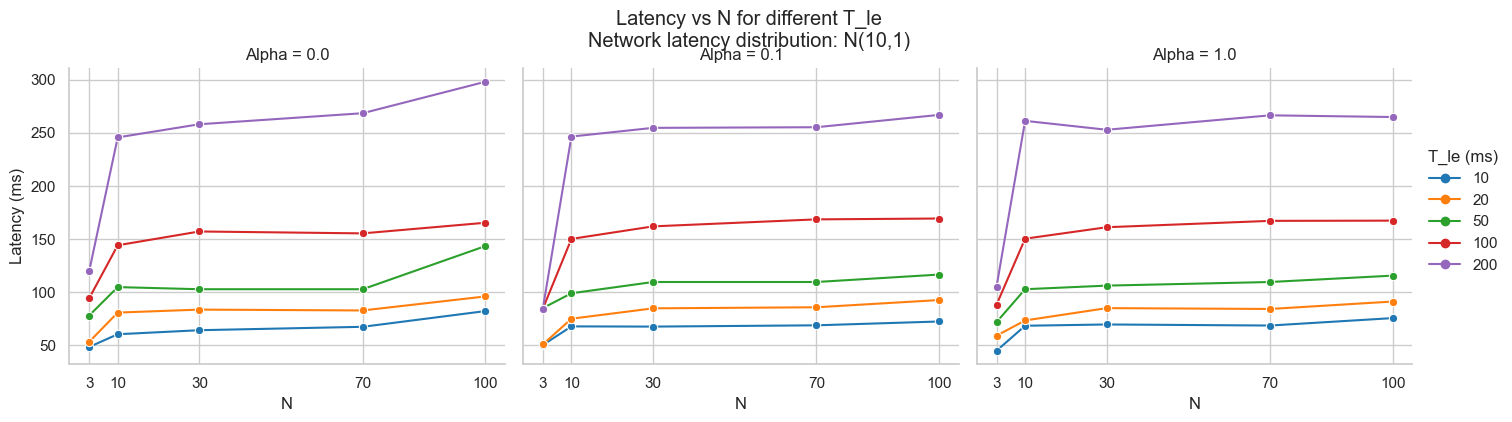

In [62]:
# Select 4 interesting T_le values and Alpha in {0, 0.1}
selected_tles = [200, 100, 50, 20, 10]
df_f1 = avg_df[(avg_df['Alpha'].isin([0.0, 0.1, 1.0])) & (avg_df['T_le'].isin(selected_tles))].copy()

df_f1.rename(columns={"Latency": "Latency (ms)", "T_le": "T_le (ms)"}, inplace=True)

g1 = sns.relplot(
    data=df_f1,
    x="N",
    y="Latency (ms)",
    hue="T_le (ms)",
    col="Alpha",
    kind="line",
    marker="o",
    palette="tab10",
    height=4,
    aspect=1.2
)

g1.fig.suptitle(f"Latency vs N for different T_le\nNetwork latency distribution: {network_latency_dist}", y=1.05)
g1.set(xticks=df_f1['N'].unique())

plt.savefig(f"{output_dir}/latency_vs_N.png", bbox_inches='tight', dpi=300)
plt.show()

## Phase Transition (Latency vs $T_{le}$)
Latency vs $T_{le}$ for a fixed $N=30$ and $\alpha=0$.

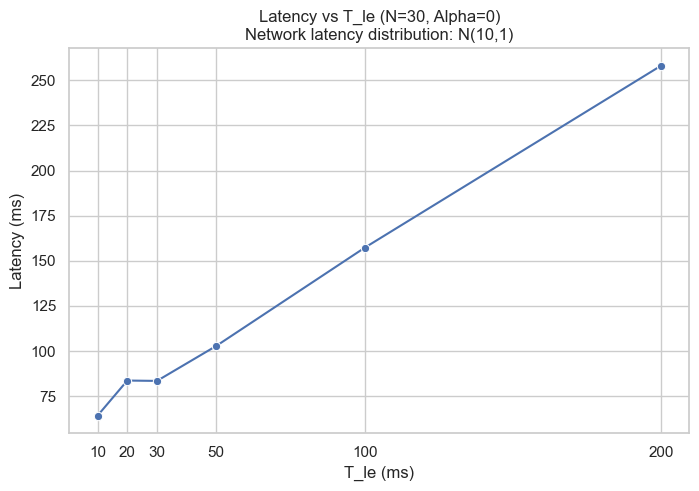

In [63]:
# We fix N=30 and Alpha=0
df_f2 = avg_df[(avg_df['N'] == 30) & (avg_df['Alpha'] == 0.0)]

plt.figure(figsize=(8, 5))
ax2 = sns.lineplot(
    data=df_f2,
    x="T_le",
    y="Latency",
    marker="o"
)

plt.title(f"Latency vs T_le (N=30, Alpha=0)\nNetwork latency distribution: {network_latency_dist}")
plt.xlabel("T_le (ms)")
plt.ylabel("Latency (ms)")

# Optional: Invert x-axis if you want Time to Decrease. We'll leave it ascending, but ensure ticks match values.
plt.xticks(sorted(df_f2['T_le'].unique(), reverse=True))

plt.savefig(f"{output_dir}/latency_vs_T_le.png", bbox_inches='tight', dpi=300)
plt.show()

## Alpha's Effect Across Scale
Grouped bar chart showing latency for different $\alpha$ values, grouped by $N$ (using a fixed mid-range $T_{le}=50$).

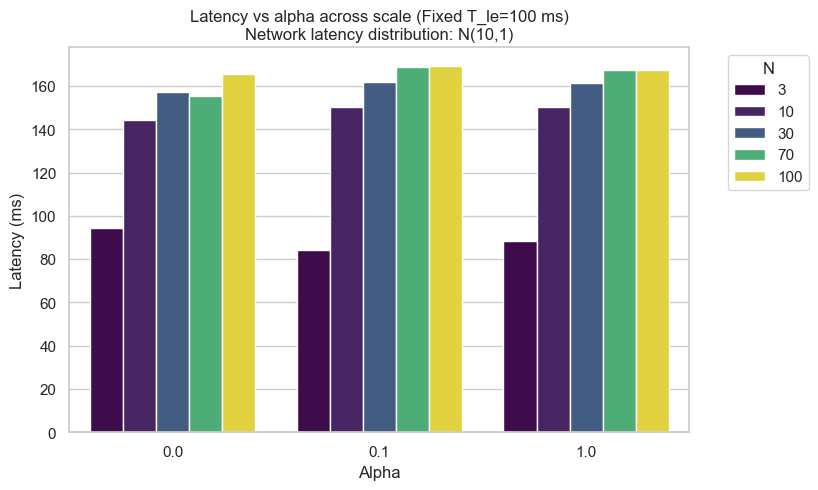

In [64]:
#Fixed T_le = 50.
df_f3 = avg_df[avg_df['T_le'] == 100]

plt.figure(figsize=(8, 5))
g3 = sns.barplot(
    data=df_f3,
    x="Alpha",
    y="Latency",
    hue="N",
    palette="viridis"
)

plt.title(f"Latency vs alpha across scale (Fixed T_le=100 ms)\nNetwork latency distribution: {network_latency_dist}")
plt.xlabel("Alpha")
plt.ylabel("Latency (ms)")

plt.legend(title="N", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig(f"{output_dir}/latency_vs_alpha.png", bbox_inches='tight', dpi=300)
plt.show()